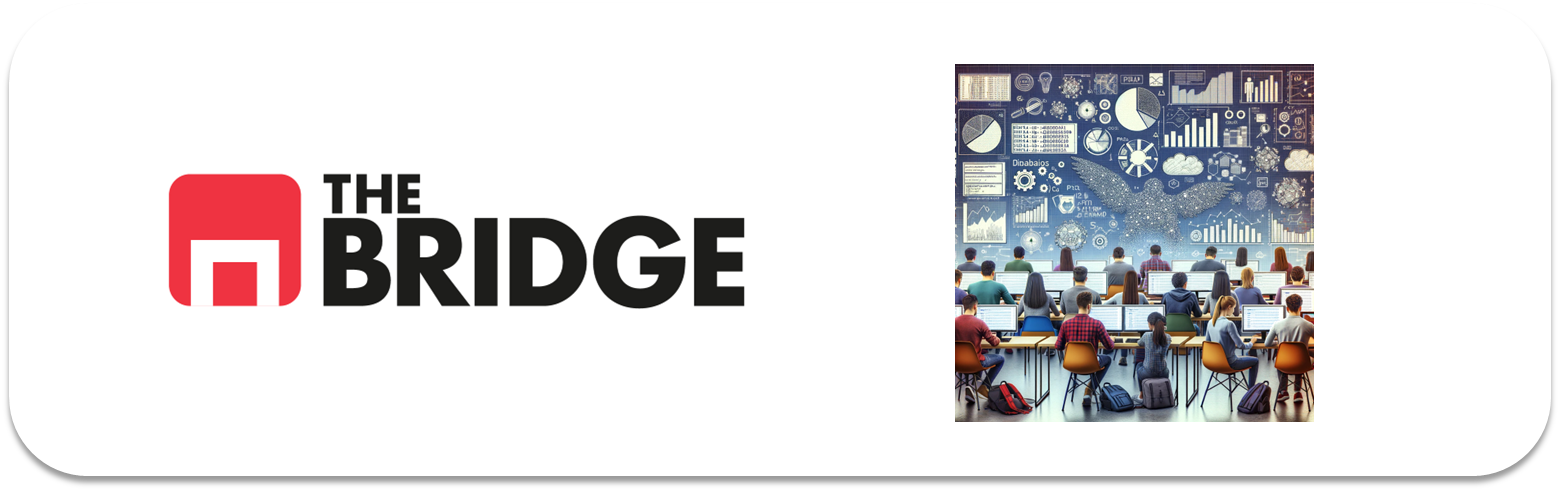

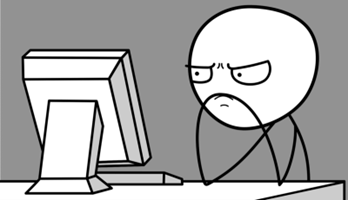

Para ejercitarte y afianzar lo aprendido sobre **Proceso de Datos**, como primera etapa de ML, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split

### Ejercicio 1

Carga el dataset de advertising que encontrarás en la carpeta de datos. Muestra su información general. ¿Qué te llama la atención? ¿Tendremos que limpiar alguna variable?

In [3]:
df = pd.read_csv("./data/advertising_ml.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   object 
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 78.3+ KB


In [4]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35 years,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31 years,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26 years,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29 years,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35 años,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [5]:
df["Ad Topic Line"].unique()

array(['Cloned 5thgeneration orchestration',
       'Monitored national standardization',
       'Organic bottom-line service-desk',
       'Triple-buffered reciprocal time-frame',
       'Robust logistical utilization', 'Sharable client-driven software',
       'Enhanced dedicated support', 'Reactive local challenge',
       'Configurable coherent function',
       'Mandatory homogeneous architecture',
       'Centralized neutral neural-net',
       'Team-oriented grid-enabled Local Area Network',
       'Centralized content-based focus group',
       'Synergistic fresh-thinking array',
       'Grass-roots coherent extranet',
       'Persistent demand-driven interface',
       'Customizable multi-tasking website', 'Intuitive dynamic attitude',
       'Grass-roots solution-oriented conglomeration',
       'Advanced 24/7 productivity',
       'Object-based reciprocal knowledgebase',
       'Streamlined non-volatile analyzer',
       'Mandatory disintermediate utilization',
       'Futur

In [6]:
df["Clicked on Ad"].value_counts()

Clicked on Ad
0    500
1    500
Name: count, dtype: int64

"Male" y "Clicked on Ad" son  variables booleanas, tipo 0/1.    
"Ad Topic Line" hace referencia al tipo de anuncio, ¿?.

### Ejercicio 2

Tenemos que entender el problema antes de seguir. Nos dicen que la compañía "QuickRespond" quiere poder generar un modelo que a partir de datos como los del dataset para poder dirigir mejor su campaña de anuncios. Hablando con ellos llegamos a la conclusión de que queremos un modelo para poder predecir si un usuario pulsará en el link de un anuncio o no. ¿Qué tipo de problemas estamos tratando?¿Y de que tipo de aprendizaje?¿Existe una variable target que puedas identificar rapidamente?

Tarea de clasificación, pulsar anuncio ---> Si/NO (en el dataset 0/1).  
Aprendizaje supervisado.  
Target ---> "Clicked on Ad"

### Ejercicio 3

Volvamos ya a los datos. Intenta dar una definición de cada columna, obten su cardinalidad y en función de esta y del tipo de variable de pandas, clasifícalas en categóricas y numéricas.

In [7]:
df_tipificacion = pd.DataFrame([df.nunique(), df.nunique()/len(df) * 100, df.dtypes]).T.rename(columns = {0: "Card",\
                                1: "%_Card", 2: "Tipo"})
df_tipificacion

,Card,%_Card,Tipo
Daily Time Spent on Site,900,90.0,float64
Age,83,8.3,object
Area Income,1000,100.0,float64
Daily Internet Usage,966,96.6,float64
Ad Topic Line,1000,100.0,object
City,969,96.9,object
Male,2,0.2,int64
Country,237,23.7,object
Timestamp,1000,100.0,object
Clicked on Ad,2,0.2,int64


In [8]:
df.columns

Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad'],
      dtype='object')

| variable   | descripción  |  clasificación |
|---|---|---|
| Daily Time Spent on Site | Tiempo en el sitio  |   |
| Age  | Edad del usuario  |   |
| Area Income  | ingresos ¿medios? del area donde se encuentra el usuario, ¿?  |   |
| Daily Internet Usage  | Tiempo medio que pasa en Internet  |   |
|Ad Topic Line   |  Hace referencia al tipo de anuncio,¿? |   |
| City  | Ciudad |   |
| Male  | Si es hombre o no  |   |
| Country  |  País |   |
| Timestamp  | registro digital que indica la fecha y hora exactas en que ocurrió un evento  |   |
| Clicked on Ad  | Si ha pulsado o no en el anuncio   |   |

In [22]:
df_tipificacion["Clasificada_como"] = "Categorica" # PArtiendo de que casi todas parecen categóricas
df_tipificacion.loc[df_tipificacion.Card == 2, "Clasificada_como"] = "Binaria"
df_tipificacion.loc[(df_tipificacion["Card"] > 10) & (df_tipificacion.Tipo != "object"), "Clasificada_como"] ="Numerica Discreta"
df_tipificacion.loc[(df_tipificacion["%_Card"] > 30) & (df_tipificacion.Tipo != "object") , "Clasificada_como"] = "Numerica Continua"
df_tipificacion

,Card,%_Card,Tipo,Clasificada_como
Daily Time Spent on Site,900,90.0,float64,Numerica Continua
Age,83,8.3,object,Categorica
Area Income,1000,100.0,float64,Numerica Continua
Daily Internet Usage,966,96.6,float64,Numerica Continua
Ad Topic Line,1000,100.0,object,Categorica
City,969,96.9,object,Categorica
Male,2,0.2,int64,Binaria
Country,237,23.7,object,Categorica
Timestamp,1000,100.0,object,Categorica
Clicked on Ad,2,0.2,int64,Binaria


### Ejercicio 4

Limpia las columnas que necesiten ser limpiadas, no completes nulos (porque asignar valores a nulos sólo puedes hacerlo primero con el train, ya explicaremos con detalle por qué). 

In [27]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [28]:
df['Timestamp'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: Timestamp
Non-Null Count  Dtype         
--------------  -----         
1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 7.9 KB


### Ejercicio 5

Divide el datset en train y test, empleando sklearn para ello tal y como hemos hecho en el workout. Usa la regla del 80-20

In [29]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

### Ejercicio 6

Haz un pequeño análisis univariante de las columnas numéricas (muestra sus histogramas)

In [30]:
from bootcampviztools import pinta_distribucion_categoricas, plot_categorical_numerical_relationship, plot_grouped_histograms

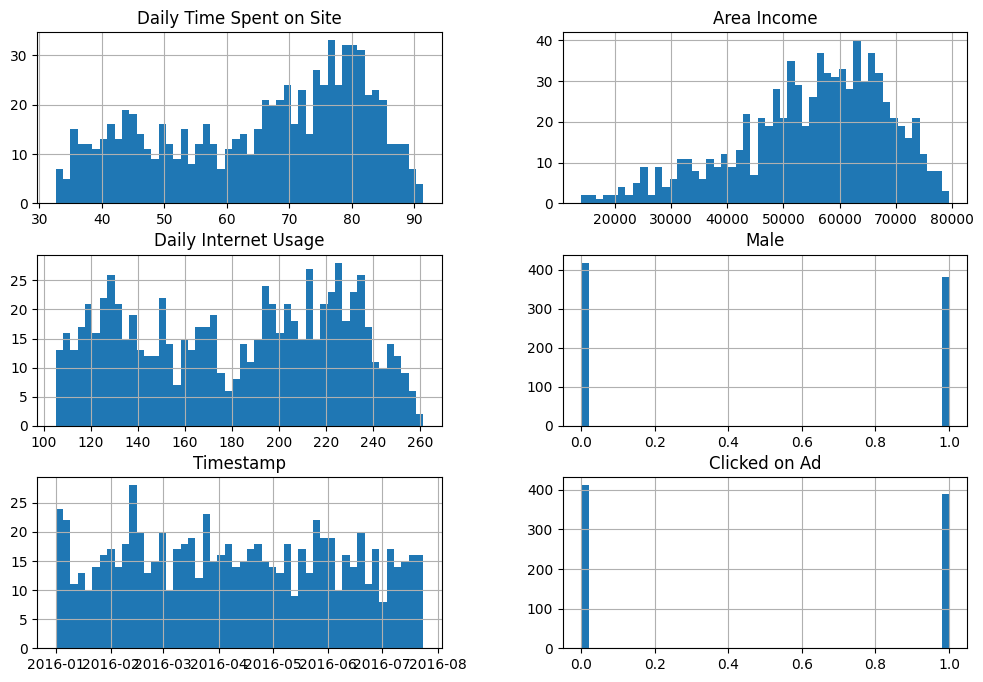

In [35]:
train_set.hist(bins=50, figsize=(12, 8)) # La forma de generar histogramas de una sola vez para las variables numéricas de un dataset
plt.show()

### Ejercicio 7

Muestra las correlaciones de las variables continuas con un "PairPlot" y emplea como codigo de color la variable target. [Esto es otra forma de hacer un bivariante y un multivariante a la vez]. Para ello como argumento del pairplot de seaborn usa el dataframe de train (no la matriz de correlación)

In [37]:
corr_matrix = train_set.corr(numeric_only= True)
print(corr_matrix)

                          Daily Time Spent on Site  Area Income  \
Daily Time Spent on Site                  1.000000     0.310189   
Area Income                               0.310189     1.000000   
Daily Internet Usage                      0.538092     0.366520   
Male                                     -0.029358    -0.019635   
Clicked on Ad                            -0.745492    -0.498504   

                          Daily Internet Usage      Male  Clicked on Ad  
Daily Time Spent on Site              0.538092 -0.029358      -0.745492  
Area Income                           0.366520 -0.019635      -0.498504  
Daily Internet Usage                  1.000000  0.037744      -0.812130  
Male                                  0.037744  1.000000      -0.043798  
Clicked on Ad                        -0.812130 -0.043798       1.000000  


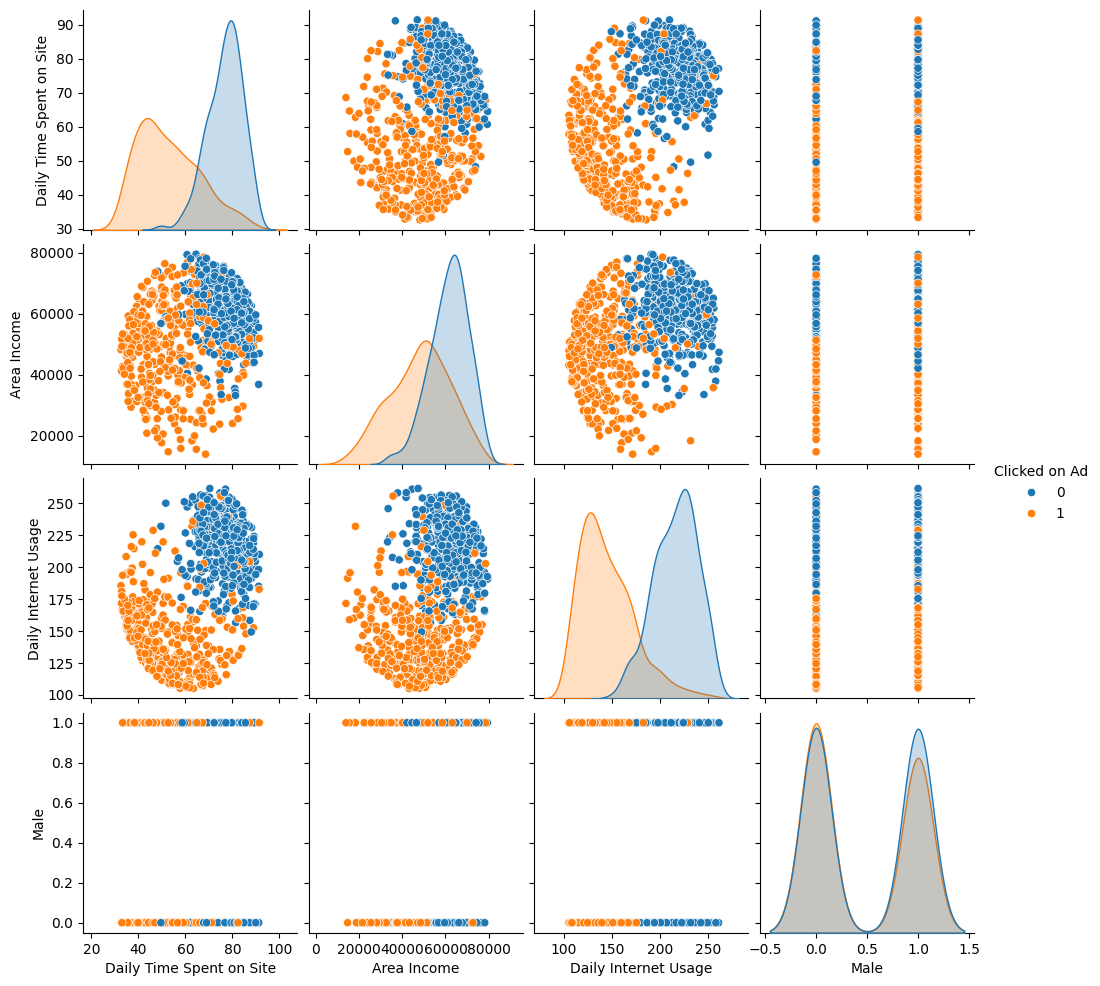

In [39]:
sns.pairplot(train_set, hue="Clicked on Ad");

In [40]:
df.columns

Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad'],
      dtype='object')

### Ejercicio 8

Fijándote en la diagonal principal del gráfico anterior haz una selecció de features:

Features = 'Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Country'.

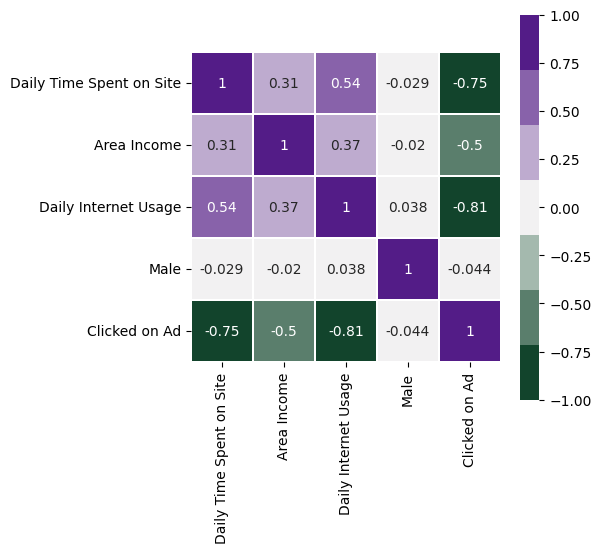

In [41]:
plt.figure(figsize=(5,5))
sns.heatmap(corr_matrix,
            vmin=-1,
            vmax=1,
            cmap=sns.diverging_palette(145, 280, s=85, l=25, n=7),
            square=True,
            linewidths=.1,
            annot=True);

Observando el gráfico, la correlación entre "Male" y "Clicked on Ad" es de -0.044, que es prácticamente nula o muy débil.  
Razones para descartar "Male":

Correlación insignificante: Un valor de -0.044 indica que prácticamente no existe relación lineal entre el género (Male) y si alguien hace clic en un anuncio. Esta correlación es tan baja que la variable no aporta poder predictivo significativo al modelo.   
Umbral de relevancia: Generalmente, se consideran correlaciones relevantes aquellas que superan ciertos umbrales (por ejemplo, |0.3| o |0.5| dependiendo del contexto). Con -0.044, Male está muy por debajo de cualquier umbral razonable.  

Comparación con otras variables: Si observas las otras variables, tienen correlaciones mucho más fuertes con "Clicked on Ad":

Daily Time Spent on Site: -0.75
Area Income: -0.5
Daily Internet Usage: -0.81



Estas variables tienen un poder predictivo mucho mayor, por lo que tiene sentido enfocarse en ellas y descartar "Male" para simplificar el modelo sin perder capacidad predictiva.